# LAB 03 - Word Embeddings: Experiments

Co-occurrence tự cài đặt (`cooccurrence.py`) và Word2Vec (`gensim`) trên corpus C4.

## 0. Setup

In [1]:
import json
import os
import random
import re
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from gensim.test.utils import datapath
from scipy.stats import spearmanr
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

from cooccurrence import (
    analogy, build_cooccurrence_matrix, build_vocabulary, cosine_similarity,
    index_to_word, matrix_stats, most_similar, ppmi, preprocess_documents,
    reduce_dimension, tokenize, word_similarity,
)

CORPUS_PATH = Path(r"E:/hus/nlp/c4-train.00000-of-01024-30K.json/c4-train.00000-of-01024-30K.json")
SEED = 42
WORKERS = os.cpu_count()
# Tuỳ chọn: thư mục lưu model đã train để chạy lại notebook nhanh hơn (None = luôn train lại)
CACHE_DIR = os.environ.get("W2V_CACHE")

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_colwidth", 120)

results = []  # mỗi dòng: experiment, model, setting, item, metric, value

def log(experiment, model, setting, item, metric, value):
    results.append({"experiment": experiment, "model": model, "setting": setting,
                    "item": item, "metric": metric, "value": value})

## 1. Corpus

C4, 30,000 document, tokenize giống LAB 02, không bỏ stopword.

In [2]:
with open(CORPUS_PATH, encoding="utf-8") as f:
    docs = [json.loads(line)["text"] for line in f]

doc_sents = [preprocess_documents([d]) for d in docs]   # câu theo từng document
sentences = [s for ds in doc_sents for s in ds]
word_freq = Counter(w for s in sentences for w in s)
N_TOKENS = sum(word_freq.values())

corpus_stats = pd.DataFrame([{
    "documents": len(docs),
    "sentences": len(sentences),
    "tokens": N_TOKENS,
    "vocabulary (types)": len(word_freq),
    "types count >= 5": sum(1 for c in word_freq.values() if c >= 5),
    "avg sentence length": N_TOKENS / len(sentences),
}])
corpus_stats

,documents,sentences,tokens,vocabulary (types),types count >= 5,avg sentence length
0,30000,634941,10972827,196397,53644,17.2816


In [3]:
probe = ["doctor", "physician", "hospital", "patient", "disease", "nurse", "computer", "football",
         "banana", "car", "automobile", "king", "queen", "cat", "dog", "bank", "river", "money"]
pd.DataFrame([{"word": w, "count": word_freq[w]} for w in probe]).set_index("word").T

word,doctor,physician,hospital,patient,disease,nurse,computer,football,banana,car,automobile,king,queen,cat,dog,bank,river,money
count,773,265,954,983,1098,324,1776,1002,116,3338,139,857,424,652,1128,1484,1088,3915


## 2. Experiment 1 - Word-context matrix trên corpus nhỏ

Corpus 16 câu tự tạo, bỏ `the`, `a`, `at` khỏi vocabulary. Thử window 1, 2, 5.

In [4]:
toy_corpus = [
    "the doctor treated the patient",
    "the physician treated the patient",
    "the doctor works at the hospital",
    "the physician works at the clinic",
    "the nurse helped the patient at the hospital",
    "the patient visited the doctor",
    "the cat eats fish",
    "the dog eats meat",
    "the cat likes milk",
    "the dog likes fish",
    "the man drives a car",
    "the woman drives a car",
    "the car needs fuel",
    "she eats a banana",
    "he likes a banana",
    "the doctor drives a car",
]
TOY_STOP = {"the", "a", "at"}
toy_vocab = build_vocabulary(toy_corpus, stopwords=TOY_STOP)
print(len(toy_vocab), "words:", list(toy_vocab))

X1 = build_cooccurrence_matrix(toy_corpus, toy_vocab, window=1, dense=True)
toy_words = index_to_word(toy_vocab)
pd.DataFrame(X1.astype(int), index=toy_words, columns=toy_words)

26 words: ['car', 'doctor', 'patient', 'drives', 'eats', 'likes', 'banana', 'cat', 'dog', 'fish', 'hospital', 'physician', 'treated', 'works', 'clinic', 'fuel', 'he', 'helped', 'man', 'meat', 'milk', 'needs', 'nurse', 'she', 'visited', 'woman']


,car,doctor,patient,drives,eats,likes,banana,cat,dog,fish,...,he,helped,man,meat,milk,needs,nurse,she,visited,woman
car,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
doctor,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
patient,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
drives,0,1,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
eats,0,0,0,0,0,0,0,1,1,1,...,0,0,0,1,0,0,0,1,0,0
likes,0,0,0,0,0,0,0,1,1,1,...,1,0,0,0,1,0,0,0,0,0
banana,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
cat,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
dog,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
fish,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
toy_pairs = [("doctor", "physician"), ("doctor", "nurse"), ("doctor", "hospital"),
             ("cat", "dog"), ("man", "woman"), ("doctor", "banana"), ("cat", "car")]

rows = []
toy_mats = {}
for w in (1, 2, 5):
    X = build_cooccurrence_matrix(toy_corpus, toy_vocab, window=w)
    toy_mats[w] = X
    st = matrix_stats(X)
    row = {"window": w, "vocabulary_size": st["vocabulary_size"], "matrix_size": st["matrix_size"],
           "non_zero": st["non_zero"], "density": st["density"]}
    for a, b in toy_pairs:
        row[f"{a}-{b}"] = word_similarity(a, b, X, toy_vocab)
        log("exp1_toy", "count", f"window={w}", f"{a}-{b}", "cosine", row[f"{a}-{b}"])
    for k in ("vocabulary_size", "non_zero", "density"):
        log("exp1_toy", "count", f"window={w}", "matrix", k, row[k])
    rows.append(row)
toy_df = pd.DataFrame(rows).set_index("window")
toy_df.T

window,1,2,5
vocabulary_size,26,26,26
matrix_size,26 x 26,26 x 26,26 x 26
non_zero,42,64,92
density,0.0621,0.0947,0.1361
doctor-physician,0.8165,0.7071,0.6325
doctor-nurse,0.0000,0.0000,0.4472
doctor-hospital,0.0000,0.0000,0.4743
cat-dog,1.0000,0.7500,0.7500
man-woman,1.0000,1.0000,1.0000
doctor-banana,0.0000,0.0000,0.0000


In [6]:
for w in (1, 2, 5):
    print(f"window={w}  most_similar(doctor):",
          [(x, round(s, 3)) for x, s in most_similar("doctor", toy_mats[w], toy_vocab, top_k=5)])

window=1  most_similar(doctor): [('physician', 0.816), ('man', 0.577), ('woman', 0.577), ('banana', 0.0), ('car', 0.0)]
window=2  most_similar(doctor): [('physician', 0.707), ('patient', 0.612), ('man', 0.5), ('woman', 0.5), ('car', 0.452)]
window=5  most_similar(doctor): [('physician', 0.632), ('helped', 0.548), ('treated', 0.516), ('hospital', 0.474), ('visited', 0.447)]


In [7]:
# Kiểm tra lại Bài 1 (calculations.md): corpus 4 câu, window = 1, bỏ "the"
bai1 = ["the cat eats fish", "the dog eats fish", "the cat likes milk", "the dog likes meat"]
v1 = build_vocabulary(bai1, stopwords={"the"})
order = ["cat", "dog", "eats", "likes", "fish", "milk", "meat"]
B = build_cooccurrence_matrix(bai1, v1, window=1, dense=True)
idx = [v1[w] for w in order]
bai1_df = pd.DataFrame(B[np.ix_(idx, idx)].astype(int), index=order, columns=order)
display(bai1_df.loc[["cat", "dog", "eats", "likes"]])
print("cos(cat, dog) =", cosine_similarity(B[v1["cat"]], B[v1["dog"]]))
print("cos(eats, likes) =", round(cosine_similarity(B[v1["eats"]], B[v1["likes"]]), 4))

,cat,dog,eats,likes,fish,milk,meat
cat,0,0,1,1,0,0,0
dog,0,0,1,1,0,0,0
eats,1,1,0,0,2,0,0
likes,1,1,0,0,0,1,1


cos(cat, dog) = 0.9999999999999998
cos(eats, likes) = 0.4082


**Nhận xét:**
- Window càng lớn thì ma trận càng nhiều ô khác 0 (42 → 92). Vocabulary không đổi.
- Window 1 cho thấy các từ thay thế được cho nhau (cat–dog = 1). Window 5 cho thấy các từ cùng chủ đề (doctor–hospital tăng từ 0 lên 0.47).
- Kết quả trên ma trận của Bài 1 khớp với tính tay.

## 3. Co-occurrence trên C4: count → PPMI → SVD

Vocabulary là 20,000 từ phổ biến nhất. Với mỗi window (1, 2, 5), so sánh ba biểu diễn: đếm thô, PPMI và SVD 100 chiều.

In [8]:
c4_vocab = build_vocabulary(sentences, min_count=5, max_size=20_000)
print("|V| =", len(c4_vocab))

eval_pairs = [("doctor", "physician"), ("doctor", "hospital"), ("doctor", "nurse"), ("cat", "dog"),
              ("king", "queen"), ("car", "automobile"), ("computer", "banana")]

co_models = {}   # (window, kind) -> matrix
stat_rows, sim_rows = [], []
for w in (1, 2, 5):
    t0 = time.time()
    X = build_cooccurrence_matrix(sentences, c4_vocab, window=w)
    t_build = time.time() - t0
    P = ppmi(X)
    t0 = time.time()
    E = reduce_dimension(P, dim=100)
    t_svd = time.time() - t0
    co_models[(w, "count")], co_models[(w, "ppmi")], co_models[(w, "svd")] = X, P, E

    st = matrix_stats(X)
    st_p = matrix_stats(P)
    stat_rows.append({"window": w, "vocabulary_size": st["vocabulary_size"], "matrix_size": st["matrix_size"],
                      "non_zero (count)": st["non_zero"], "density (count)": st["density"],
                      "non_zero (ppmi)": st_p["non_zero"], "dense_MB": st["dense_MB"],
                      "sparse_MB": st["sparse_MB"], "svd_MB": E.nbytes / 2**20,
                      "build_s": t_build, "svd_s": t_svd})
    for k in ("non_zero", "density", "sparse_MB", "dense_MB"):
        log("exp1_c4", "count", f"window={w}", "matrix", k, st[k])
    log("exp1_c4", "ppmi", f"window={w}", "matrix", "non_zero", st_p["non_zero"])

    for kind, M in (("count", X), ("ppmi", P), ("svd", E)):
        row = {"window": w, "representation": kind}
        for a, b in eval_pairs:
            row[f"{a}-{b}"] = word_similarity(a, b, M, c4_vocab)
            log("exp1_c4", kind, f"window={w}", f"{a}-{b}", "cosine", row[f"{a}-{b}"])
        sim_rows.append(row)

pd.DataFrame(stat_rows).set_index("window")

|V| = 20000


,vocabulary_size,matrix_size,non_zero (count),density (count),non_zero (ppmi),dense_MB,sparse_MB,svd_MB,build_s,svd_s
window,,,,,,,,,,
1,20000,20000 x 20000,3618871,0.0090,3032204,"3,051.7578",41.4910,15.2588,9.1929,9.6654
2,20000,20000 x 20000,6915141,0.0173,5585459,"3,051.7578",79.2138,15.2588,13.2082,11.9370
5,20000,20000 x 20000,14075483,0.0352,10824743,"3,051.7578",161.1574,15.2588,15.9096,18.3499


In [9]:
co_sim_df = pd.DataFrame(sim_rows).set_index(["window", "representation"])
co_sim_df

doctor-physician  doctor-hospital  doctor-nurse  \
window representation                                                    
1      count                     0.9163           0.6518        0.6481   
       ppmi                      0.1552           0.0957        0.1039   
       svd                       0.7222           0.3462        0.6439   
2      count                     0.9298           0.7531        0.7888   
       ppmi                      0.1693           0.0871        0.1181   
       svd                       0.8120           0.4690        0.5992   
5      count                     0.9487           0.8410        0.8741   
       ppmi                      0.2052           0.1467        0.1433   
       svd                       0.8255           0.6245        0.5947   

                       cat-dog  king-queen  car-automobile  computer-banana  
window representation                                                        
1      count            0.8734      0.8808          0.7608           0.5746  
       ppmi             0.1777      0.1577          0.1864           0.0229  
       svd              0.7721      0.6024          0.6180           0.0212  
2      count            0.9209      0.9188          0.8494           0.6950  
       ppmi             0.1831      0.1897          0.1643           0.0234  
       svd              0.8231      0.7659          0.6202           0.0113  
5      count            0.9560      0.9544          0.9312           0.8089  
       ppmi             0.2077      0.2217          0.1681           0.0298  
       svd              0.8322      0.7976          0.6033           0.0450

In [10]:
# Nếu vocabulary có 100,000 từ (mục 12)
for V in (20_000, 100_000):
    print(f"|V| = {V:,}: {V*V:,} ô, dense float64 = {V*V*8/2**30:,.1f} GB; "
          f"embedding 300 chiều = {V*300*4/2**20:,.0f} MB (float32)")

|V| = 20,000: 400,000,000 ô, dense float64 = 3.0 GB; embedding 300 chiều = 23 MB (float32)
|V| = 100,000: 10,000,000,000 ô, dense float64 = 74.5 GB; embedding 300 chiều = 114 MB (float32)


In [11]:
co_words = ["doctor", "hospital", "patient", "disease", "computer", "football", "banana"]
rows = []
for kind in ("count", "ppmi", "svd"):
    M = co_models[(5, kind)]
    for word in co_words:
        top = most_similar(word=word, matrix=M, vocabulary=c4_vocab, top_k=5)
        rows.append({"representation": kind, "word": word,
                     "top5": ", ".join(f"{x} ({s:.2f})" for x, s in top)})
        for r, (x, s) in enumerate(top, 1):
            log("core_most_similar", kind, "window=5", word, f"top{r}", f"{x}:{s:.4f}")
pd.DataFrame(rows).set_index(["representation", "word"])

top5
representation word                                                                                            
count          doctor                   child (0.97), dentist (0.95), physician (0.95), dog (0.94), plan (0.94)
               hospital             community (0.95), park (0.95), house (0.95), public (0.95), location (0.95)
               patient                   proper (0.97), test (0.96), function (0.96), for (0.96), client (0.96)
               disease   treatment (0.94), activity (0.93), natural (0.93), performance (0.93), strength (0.93)
               computer               business (0.95), home (0.95), budget (0.94), desktop (0.94), child (0.94)
               football                 kits (0.86), shirt (0.81), kingdom (0.79), emperor (0.76), cheap (0.74)
               banana                      red (0.91), texture (0.91), bread (0.91), white (0.91), fruit (0.91)
ppmi           doctor         doctors (0.22), medical (0.22), patients (0.21), physician (0.21), surgery (0.19)
               hospital          medical (0.25), university (0.23), care (0.22), medicine (0.22), clinic (0.21)
               patient          patients (0.28), treatment (0.24), care (0.23), clinical (0.23), medical (0.22)
               disease      diseases (0.44), chronic (0.34), patients (0.34), diabetes (0.33), disorders (0.33)
               computer             software (0.28), laptop (0.25), computers (0.25), device (0.23), usb (0.23)
               football           replica (0.44), shirt (0.33), shirts (0.28), basketball (0.25), soccer (0.24)
               banana                 butter (0.27), pudding (0.24), fruit (0.23), peanut (0.23), yogurt (0.23)
svd            doctor          physician (0.83), doctors (0.81), doctor's (0.75), dentist (0.74), clinic (0.74)
               hospital           medical (0.77), clinic (0.76), care (0.72), hospice (0.72), outpatient (0.71)
               patient      patients (0.83), diagnosis (0.77), patient's (0.75), clinical (0.73), doctor (0.72)
               disease    diseases (0.96), infections (0.88), cancer (0.86), autoimmune (0.86), diabetes (0.85)
               computer          computers (0.79), device (0.75), devices (0.72), laptop (0.70), desktop (0.69)
               football        hockey (0.85), baseball (0.85), basketball (0.84), soccer (0.78), replica (0.77)
               banana           caramel (0.84), peanut (0.84), pudding (0.84), apples (0.82), strawberry (0.82)

**Nhận xét:**
- Ma trận có 4 × 10^8 ô nhưng chỉ 1–4% khác 0. Lưu dạng sparse cần 41–161 MB, nếu dense thì cần 3 GB.
- Đếm thô gần như vô dụng: mọi cặp từ đều có cosine cao (computer–banana = 0.81), vì vector bị chi phối bởi các từ the, a, of.
- PPMI cho thứ hạng hợp lý. SVD cho kết quả tốt nhất: doctor → physician (0.83), dentist, clinic.

## 4. Training pairs CBOW / Skip-gram

Kiểm tra lại bài tính tay ở mục 16.

In [12]:
def training_pairs(sentence, window=1):
    tokens = sentence.split()
    cbow, skipgram = [], []
    for i, target in enumerate(tokens):
        context = tokens[max(0, i - window):i] + tokens[i + 1:i + 1 + window]
        cbow.append((context, target))
        skipgram.extend((target, c) for c in context)
    return cbow, skipgram

cbow, skipgram = training_pairs("the cat eats fish", window=1)
print("CBOW (context -> target):")
for c, t in cbow:
    print("  ", c, "->", t)
print(f"Skip-gram (target -> context), {len(skipgram)} pairs:")
for t, c in skipgram:
    print("  ", t, "->", c)

CBOW (context -> target):
   ['cat'] -> the
   ['the', 'eats'] -> cat
   ['cat', 'fish'] -> eats
   ['eats'] -> fish
Skip-gram (target -> context), 6 pairs:
   the -> cat
   cat -> the
   cat -> eats
   eats -> cat
   eats -> fish
   fish -> eats


## 5. Experiment 2 - Word2Vec

| Tham số | Giá trị |
|---|---|
| corpus | C4, 30,000 document |
| vocabulary | các từ có count ≥ 5 |
| vector_size / window / min_count / epochs | 100 / 5 / 5 / 10 |
| objective | Skip-gram + negative sampling (5). So sánh thêm CBOW |

In [13]:
BASE = dict(vector_size=100, window=5, min_count=5, epochs=10, sg=1, negative=5, hs=0, sample=1e-3)
w2v_models, w2v_times = {}, {}

def train_w2v(name, corpus=None, **overrides):
    """Train (hoặc nạp từ CACHE_DIR) một Word2Vec model, trả về (model, giây train)."""
    params = {**BASE, **overrides}
    if CACHE_DIR:
        path = Path(CACHE_DIR) / f"{name}.model"
        if path.exists():
            meta = json.loads(path.with_suffix(".json").read_text())
            model = Word2Vec.load(str(path))
            w2v_models[name], w2v_times[name] = model, meta["train_s"]
            return model, meta["train_s"]
    t0 = time.time()
    model = Word2Vec(sentences=corpus if corpus is not None else sentences,
                     seed=SEED, workers=WORKERS, **params)
    elapsed = time.time() - t0
    if CACHE_DIR:
        Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)
        model.save(str(path))
        path.with_suffix(".json").write_text(json.dumps({"train_s": elapsed, "params": params}))
    w2v_models[name], w2v_times[name] = model, elapsed
    return model, elapsed

sg_model, t_sg = train_w2v("sg_w5_d100")
cbow_model, t_cbow = train_w2v("cbow_w5_d100", sg=0)

def model_size_mb(model):
    # input vectors (wv) + output vectors (syn1neg), float32
    return (model.wv.vectors.nbytes + model.syn1neg.nbytes) / 2**20

pd.DataFrame([
    {"model": "Skip-gram", "vocabulary": len(sg_model.wv), "train_s": t_sg, "size_MB": model_size_mb(sg_model),
     "trained_words": sg_model.corpus_total_words},
    {"model": "CBOW", "vocabulary": len(cbow_model.wv), "train_s": t_cbow, "size_MB": model_size_mb(cbow_model),
     "trained_words": cbow_model.corpus_total_words},
]).set_index("model")

,vocabulary,train_s,size_MB,trained_words
model,,,,
Skip-gram,53644,247.2272,40.9271,10972827
CBOW,53644,106.8502,40.9271,10972827


In [14]:
for name, m, t in (("Skip-gram", sg_model, t_sg), ("CBOW", cbow_model, t_cbow)):
    log("exp2_word2vec", name, "d=100,w=5", "model", "vocabulary_size", len(m.wv))
    log("exp2_word2vec", name, "d=100,w=5", "model", "train_seconds", t)

inspect_words = ["doctor", "hospital", "patient", "disease", "computer", "football", "banana"]
rows = []
for word in inspect_words:
    for name, m in (("Skip-gram", sg_model), ("CBOW", cbow_model)):
        top = m.wv.most_similar(word, topn=5)
        rows.append({"word": word, "model": name, "top5": ", ".join(f"{x} ({s:.2f})" for x, s in top)})
        for r, (x, s) in enumerate(top, 1):
            log("exp2_inspect", name, "d=100,w=5", word, f"top{r}", f"{x}:{s:.4f}")
inspect_df = pd.DataFrame(rows).set_index(["word", "model"])
inspect_df

top5
word     model                                                                                                      
doctor   Skip-gram  ophthalmologist (0.78), dentist (0.77), pharmacist (0.76), veterinarian (0.74), physician (0.73)
         CBOW               dentist (0.79), veterinarian (0.73), physician (0.72), surgeon (0.71), pharmacist (0.70)
hospital Skip-gram                       upmc (0.76), clinic (0.71), icu (0.70), samitivej (0.68), pediatrics (0.67)
         CBOW                                clinic (0.77), icu (0.64), clinics (0.61), usc (0.61), hospitals (0.60)
patient  Skip-gram          patient's (0.74), patients (0.69), prescriber (0.67), optometrist (0.67), dentist (0.67)
         CBOW                    patient's (0.67), patients (0.65), physician (0.64), diagnosis (0.61), child (0.60)
disease  Skip-gram          diseases (0.86), infection (0.80), celiac (0.80), autoimmune (0.78), osteoporosis (0.77)
         CBOW                    diseases (0.80), infection (0.78), obesity (0.76), chronic (0.75), arthritis (0.75)
computer Skip-gram                   198x (0.69), phone's (0.69), laptop (0.67), computers (0.67), simulators (0.66)
         CBOW                          device (0.70), desktop (0.70), laptop (0.66), browser (0.63), software (0.63)
football Skip-gram                    replica (0.78), soccer (0.74), shirtre (0.71), shirt (0.70), basketball (0.70)
         CBOW                    replica (0.69), baseball (0.68), soccer (0.67), basketball (0.64), preseason (0.61)
banana   Skip-gram                         chutney (0.75), lentil (0.74), squash (0.74), tomato (0.73), panko (0.73)
         CBOW                    pudding (0.86), peppers (0.85), strawberries (0.84), carrot (0.84), flavored (0.84)

In [15]:
# Prediction 1: cosine giữa từng cặp trong 5 từ
p1_words = ["doctor", "physician", "hospital", "banana", "car"]
p1 = {}
for name, m in (("Skip-gram", sg_model), ("CBOW", cbow_model)):
    p1[name] = pd.DataFrame([[float(m.wv.similarity(a, b)) for b in p1_words] for a in p1_words],
                            index=p1_words, columns=p1_words)
    for i, a in enumerate(p1_words):
        for b in p1_words[i + 1:]:
            log("prediction1", name, "d=100,w=5", f"{a}-{b}", "cosine", p1[name].loc[a, b])
pd.concat(p1, axis=1)

Skip-gram                                      CBOW            \
             doctor physician hospital  banana    car  doctor physician   
doctor       1.0000    0.7278   0.5635  0.0256 0.3657  1.0000    0.7165   
physician    0.7278    1.0000   0.5966 -0.0503 0.3166  0.7165    1.0000   
hospital     0.5635    0.5966   1.0000  0.1042 0.3683  0.4840    0.5555   
banana       0.0256   -0.0503   0.1042  1.0000 0.0411 -0.1363   -0.2308   
car          0.3657    0.3166   0.3683  0.0411 1.0000  0.3060    0.1421   

                                    
          hospital  banana     car  
doctor      0.4840 -0.1363  0.3060  
physician   0.5555 -0.2308  0.1421  
hospital    1.0000 -0.1343  0.2269  
banana     -0.1343  1.0000 -0.0557  
car         0.2269 -0.0557  1.0000

**Nhận xét:** doctor–physician gần nhất (0.73), sau đó là hospital. Banana gần như không liên quan đến từ nào (≈ 0). Bất ngờ: doctor–car = 0.37, do cả hai hay xuất hiện trong văn bản quảng cáo/dịch vụ.

### Evidence từ corpus

Các context có PMI dương với cả doctor và láng giềng của nó (số lần xuất hiện cạnh doctor / cạnh láng giềng).

In [16]:
_ctx_cache = {}

def context_counter(word, window=5):
    """Counter các context word của `word` trong toàn corpus, kèm số lần xuất hiện của word."""
    if word not in _ctx_cache:
        c, n = Counter(), 0
        for s in sentences:
            if word in s:
                for i, w in enumerate(s):
                    if w == word:
                        n += 1
                        c.update(s[max(0, i - window):i] + s[i + 1:i + 1 + window])
        _ctx_cache[word] = (c, n)
    return _ctx_cache[word]

def pmi(word, ctx):
    c, _ = context_counter(word)
    return np.log(c[ctx] * N_TOKENS / (sum(c.values()) * word_freq[ctx]))

def shared_contexts(w1, w2, top=8, min_count=3):
    c1, _ = context_counter(w1)
    c2, _ = context_counter(w2)
    scores = {}
    for x in set(c1) & set(c2):
        if c1[x] >= min_count and c2[x] >= min_count:
            s = min(pmi(w1, x), pmi(w2, x))
            if s > 0:
                scores[x] = s
    best = sorted(scores, key=scores.get, reverse=True)[:top]
    return [(x, c1[x], c2[x]) for x in best]

def example_sentences(word, must=(), k=3, max_len=25, seed=SEED):
    """k câu ngẫu nhiên chứa word (và mọi từ trong must)."""
    pool = [s for s in sentences if word in s and all(m in s for m in must)]
    random.Random(seed).shuffle(pool)
    return [" ".join(s[:max_len]) for s in pool[:k]], len(pool)

rows = []
for nb, s in sg_model.wv.most_similar("doctor", topn=5):
    shared = shared_contexts("doctor", nb)
    rows.append({"neighbor": nb, "cosine": s, "count(neighbor)": word_freq[nb],
                 "shared contexts (count with doctor / neighbor)":
                     ", ".join(f"{x} ({a}/{b})" for x, a, b in shared)})
pd.DataFrame(rows).set_index("neighbor")

,cosine,count(neighbor),shared contexts (count with doctor / neighbor)
neighbor,,,
ophthalmologist,0.7785,17,"your (213/8), an (44/7), a (313/6), you (106/6), to (252/12), is (80/3), can (25/3)"
dentist,0.7677,199,"consult (23/5), dentist (5/6), doctor (20/5), appointment (5/3), tell (15/6), talk (19/3), recommend (7/5), ask (14/3)"
pharmacist,0.7599,61,"doctor (20/10), speak (8/3), licensed (4/5), tell (15/3), care (17/3), your (213/15), who (50/5), professional (8/3)"
veterinarian,0.7395,61,"consult (23/3), seek (3/3), visit (13/3), your (213/31), regular (3/3), who (50/3), about (30/3), a (313/31)"
physician,0.7278,265,"prescribe (4/3), consult (23/10), prescribed (5/5), visits (9/4), nurse (10/3), medicine (13/7), patient (12/5), med..."


In [17]:
for nb in [w for w, _ in sg_model.wv.most_similar("doctor", topn=2)] + ["physician"]:
    sents, n = example_sentences(nb, k=3)
    print(f"--- {nb} ({n} câu)")
    for s in sents:
        print("   ", s)

--- ophthalmologist (17 câu)
    lasik is a delicate procedure and just a seasoned ophthalmologist can figure out if you're a perfect candidate for lasik dependent on your general wellbeing
    for example when a person has a vision problem he or she has two options to purchase inexpensive eyeglasses at the pharmacy or to visit
    itas important to consult with your ophthalmologist in depth to learn whether lasik or any other refractive procedure is most suitable for you


--- dentist (188 câu)
    why is it important to see a dentist in weatherford while you're pregnant
    this means only you and your dentist will know you have these fillings
    if there are no dental problems the dentist may proceed to a professional dental cleaning where the plaque and tartar build up are removed to
--- physician (240 câu)
    if you are told that this is to be an observational visit get in touch with your loved one's physician and have them go to
    to have been the victim of a physician that gave you a prescription that only made you more ill or had side effects that have
    he has run nationally and internationally known cardiovascular research programs for over 40 years training dozens of medical scientists and collaborating with scores of physician


**Nhận xét:**
- Láng giềng của doctor là các nghề y (dentist, pharmacist, physician). Chúng dùng chung context như consult, appointment, prescribe.
- Có những láng giềng sai: football → replica (spam bán áo đấu), hospital → upmc (từ hiếm), banana → chutney (banana chủ yếu xuất hiện trong công thức nấu ăn).
- Skip-gram chậm hơn CBOW khoảng 2.3 lần và ưu tiên từ hiếm. CBOW ưu tiên từ phổ biến.

## 6. Experiment 3 - Context window

Skip-gram với window 2, 5, 10. Đánh giá bằng một số cặp từ, WordSim353, SimLex-999 và Google analogy.

In [18]:
WS353 = datapath("wordsim353.tsv")
SIMLEX = datapath("simlex999.txt")
ANALOGY = datapath("questions-words.txt")

def benchmark(model):
    ws = model.wv.evaluate_word_pairs(WS353)
    sl = model.wv.evaluate_word_pairs(SIMLEX)
    acc, sections = model.wv.evaluate_word_analogies(ANALOGY, restrict_vocab=30_000)
    def section_acc(names):
        c = sum(len(s["correct"]) for s in sections if s["section"] in names)
        n = sum(len(s["correct"]) + len(s["incorrect"]) for s in sections if s["section"] in names)
        return c / n if n else float("nan")
    sem = [s["section"] for s in sections if not s["section"].startswith("gram") and s["section"] != "Total accuracy"]
    syn = [s["section"] for s in sections if s["section"].startswith("gram")]
    total = sections[-1]
    return {
        "wordsim353_spearman": ws[1].statistic, "wordsim353_oov%": ws[2],
        "simlex999_spearman": sl[1].statistic, "simlex999_oov%": sl[2],
        "analogy_acc": acc, "analogy_semantic": section_acc(sem), "analogy_syntactic": section_acc(syn),
        "analogy_questions": len(total["correct"]) + len(total["incorrect"]),
    }

window_pairs = [("doctor", "physician"), ("doctor", "hospital"), ("doctor", "nurse"), ("doctor", "disease"),
                ("cat", "dog"), ("king", "queen"), ("hot", "cold"), ("computer", "banana")]

for w in (2, 10):
    train_w2v(f"sg_w{w}_d100", window=w)
window_models = {2: w2v_models["sg_w2_d100"], 5: sg_model, 10: w2v_models["sg_w10_d100"]}
window_time = {2: w2v_times["sg_w2_d100"], 5: t_sg, 10: w2v_times["sg_w10_d100"]}

pair_rows, bench_rows = [], []
for w, m in window_models.items():
    for a, b in window_pairs:
        s = float(m.wv.similarity(a, b))
        pair_rows.append({"pair": f"{a}-{b}", "window": w, "cosine": s})
        log("exp3_window", "Skip-gram", f"window={w}", f"{a}-{b}", "cosine", s)
    bench = {"window": w, "train_s": window_time[w], **benchmark(m)}
    bench_rows.append(bench)
    for k, v in bench.items():
        if k != "window":
            log("exp3_window", "Skip-gram", f"window={w}", "benchmark", k, v)

pd.DataFrame(pair_rows).pivot(index="pair", columns="window", values="cosine").loc[[f"{a}-{b}" for a, b in window_pairs]]

window,2,5,10
pair,,,
doctor-physician,0.7583,0.7278,0.6734
doctor-hospital,0.5510,0.5635,0.5581
doctor-nurse,0.6167,0.6005,0.5761
doctor-disease,0.3714,0.4560,0.4764
cat-dog,0.7376,0.7839,0.7779
king-queen,0.7088,0.7135,0.7421
hot-cold,0.7471,0.7478,0.7646
computer-banana,0.0524,0.0487,0.0676


In [19]:
window_bench = pd.DataFrame(bench_rows).set_index("window")
window_bench

,train_s,wordsim353_spearman,wordsim353_oov%,simlex999_spearman,simlex999_oov%,analogy_acc,analogy_semantic,analogy_syntactic,analogy_questions
window,,,,,,,,,
2,132.7095,0.5660,2.8329,0.3503,0.3003,0.2338,0.0908,0.3050,12820
5,247.2272,0.6182,2.8329,0.3481,0.3003,0.2767,0.1895,0.3201,12820
10,284.8657,0.6377,2.8329,0.3325,0.3003,0.2789,0.2273,0.3046,12820


In [20]:
rows = []
for w, m in window_models.items():
    for word in ("doctor", "football", "banana"):
        rows.append({"word": word, "window": w,
                     "top5": ", ".join(f"{x} ({s:.2f})" for x, s in m.wv.most_similar(word, topn=5))})
pd.DataFrame(rows).set_index(["word", "window"])

,,top5
word,window,
doctor,2,"dentist (0.79), physician (0.76), chiropractor (0.72), hygienist (0.72), veterinarian (0.71)"
football,2,"soccer (0.74), rugby (0.70), baseball (0.70), shirtre (0.70), basketball (0.69)"
banana,2,"chutney (0.80), diced (0.77), tortilla (0.77), enchilada (0.76), lentil (0.76)"
doctor,5,"ophthalmologist (0.78), dentist (0.77), pharmacist (0.76), veterinarian (0.74), physician (0.73)"
football,5,"replica (0.78), soccer (0.74), shirtre (0.71), shirt (0.70), basketball (0.70)"
banana,5,"chutney (0.75), lentil (0.74), squash (0.74), tomato (0.73), panko (0.73)"
doctor,10,"endocrinologist (0.78), obstetrician (0.75), dentist (0.74), ophthalmologist (0.73), alendronate (0.73)"
football,10,"replica (0.82), shirt (0.76), shirtre (0.75), shirts (0.74), shirtr (0.73)"
banana,10,"pecan (0.74), capers (0.72), spiced (0.72), lasagne (0.71), quesadillas (0.71)"


**Nhận xét - window lớn hơn có luôn tốt hơn không? Không.**
- Window lớn làm các từ cùng chủ đề gần nhau hơn: WordSim353 0.566 → 0.638, doctor–disease 0.37 → 0.48.
- Nhưng độ đồng nghĩa giảm: doctor–physician 0.76 → 0.67, SimLex-999 0.350 → 0.333.
- Window 10 còn khuếch đại nhiễu (football → toàn từ spam) và train chậm hơn (133 s → 285 s).

## 7. Experiment 4 - Embedding dimension

Skip-gram 50, 100 và 300 chiều. Downstream task: phân loại chủ đề của 90 từ (6 nhóm) bằng Logistic Regression, 5-fold CV.

In [21]:
categories = {
    "medical": ["doctor", "nurse", "hospital", "patient", "disease", "surgery", "medicine", "clinic",
                "therapy", "cancer", "infection", "symptoms", "dentist", "vaccine", "diagnosis"],
    "sport": ["football", "soccer", "basketball", "baseball", "tennis", "golf", "hockey", "rugby",
              "cricket", "volleyball", "team", "coach", "player", "tournament", "league"],
    "food": ["banana", "apple", "bread", "cheese", "chicken", "rice", "pasta", "soup",
             "salad", "cake", "chocolate", "potato", "tomato", "butter", "pizza"],
    "technology": ["computer", "software", "laptop", "internet", "smartphone", "keyboard", "server", "database",
                   "browser", "app", "digital", "programming", "processor", "network", "website"],
    "vehicle": ["car", "truck", "bus", "train", "bicycle", "motorcycle", "airplane", "boat",
                "vehicle", "engine", "tire", "driver", "van", "taxi", "jeep"],
    "animal": ["cat", "dog", "horse", "cow", "bird", "fish", "lion", "tiger",
               "rabbit", "sheep", "elephant", "monkey", "wolf", "bear", "deer"],
}
cat_words = [w for ws in categories.values() for w in ws]
cat_labels = [c for c, ws in categories.items() for _ in ws]
missing = [w for w in cat_words if w not in sg_model.wv or w not in c4_vocab]
print("Từ thiếu trong vocabulary:", missing)

def downstream_accuracy(features):
    X = np.asarray(features, dtype=np.float64)
    X = X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-12)
    scores = []
    for rep in range(5):
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED + rep)
        clf = LogisticRegression(max_iter=2000, C=10)
        scores.extend(cross_val_score(clf, X, cat_labels, cv=cv))
    return float(np.mean(scores)), float(np.std(scores))

Từ thiếu trong vocabulary: []


In [22]:
for d in (50, 300):
    train_w2v(f"sg_w5_d{d}", vector_size=d)
dim_models = {50: w2v_models["sg_w5_d50"], 100: sg_model, 300: w2v_models["sg_w5_d300"]}
dim_time = {50: w2v_times["sg_w5_d50"], 100: t_sg, 300: w2v_times["sg_w5_d300"]}

dim_rows = []
for d, m in dim_models.items():
    acc, std = downstream_accuracy([m.wv[w] for w in cat_words])
    row = {"dimension": d, "train_s": dim_time[d], "size_MB": model_size_mb(m),
           **{f"{a}-{b}": float(m.wv.similarity(a, b)) for a, b in window_pairs[:5]},
           **benchmark(m), "downstream_acc": acc, "downstream_std": std}
    dim_rows.append(row)
    for k, v in row.items():
        if k != "dimension":
            log("exp4_dimension", "Skip-gram", f"dim={d}", "benchmark" if "-" not in k else k,
                k if "-" not in k else "cosine", v)
dim_df = pd.DataFrame(dim_rows).set_index("dimension")
dim_df.T

dimension,50,100,300
train_s,218.3810,247.2272,331.1059
size_MB,20.4636,40.9271,122.7814
doctor-physician,0.8456,0.7278,0.5452
doctor-hospital,0.6385,0.5635,0.3479
doctor-nurse,0.7257,0.6005,0.3818
doctor-disease,0.5328,0.4560,0.2205
cat-dog,0.8497,0.7839,0.4461
wordsim353_spearman,0.5711,0.6182,0.6052
wordsim353_oov%,2.8329,2.8329,2.8329
simlex999_spearman,0.3130,0.3481,0.3792


In [23]:
baseline_rows = []
for name, M in (("PPMI (20,000 chiều, sparse)", co_models[(5, "ppmi")]), ("PPMI + SVD (100 chiều)", co_models[(5, "svd")])):
    feats = [np.asarray(M[c4_vocab[w]].todense()).ravel() if hasattr(M, "todense") else M[c4_vocab[w]] for w in cat_words]
    acc, std = downstream_accuracy(feats)
    baseline_rows.append({"features": name, "downstream_acc": acc, "downstream_std": std})
    log("exp4_dimension", name, "window=5", "benchmark", "downstream_acc", acc)
for d in (50, 100, 300):
    baseline_rows.append({"features": f"Word2Vec Skip-gram {d} chiều", "downstream_acc": dim_df.loc[d, "downstream_acc"],
                          "downstream_std": dim_df.loc[d, "downstream_std"]})
pd.DataFrame(baseline_rows).set_index("features")

,downstream_acc,downstream_std
features,,
"PPMI (20,000 chiều, sparse)",0.9822,0.0259
PPMI + SVD (100 chiều),0.9889,0.0222
Word2Vec Skip-gram 50 chiều,0.9889,0.0222
Word2Vec Skip-gram 100 chiều,0.9778,0.0272
Word2Vec Skip-gram 300 chiều,0.9867,0.0237


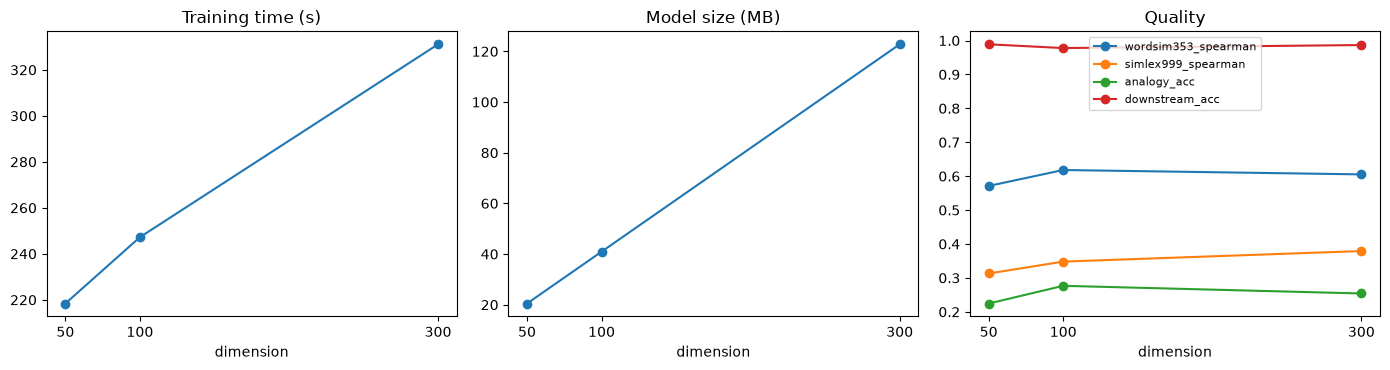

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
dims = list(dim_df.index)
axes[0].plot(dims, dim_df["train_s"], "o-"); axes[0].set_title("Training time (s)")
axes[1].plot(dims, dim_df["size_MB"], "o-"); axes[1].set_title("Model size (MB)")
for col in ("wordsim353_spearman", "simlex999_spearman", "analogy_acc", "downstream_acc"):
    axes[2].plot(dims, dim_df[col], "o-", label=col)
axes[2].set_title("Quality"); axes[2].legend(fontsize=8)
for ax in axes:
    ax.set_xlabel("dimension"); ax.set_xticks(dims)
plt.tight_layout(); plt.show()

**Nhận xét:**
- Model size tăng tuyến tính (20 → 41 → 123 MB), training time tăng 218 s → 331 s.
- Chất lượng không tăng đều: WordSim353 và analogy tốt nhất ở 100 chiều. Downstream đã bão hoà (≈ 0.98).
- Cosine tuyệt đối giảm khi dimension tăng, nên không so cosine giữa các model khác dimension.

## 8. Corpus size (Prediction 4)

Thử ba trường hợp: 100 câu ngẫu nhiên, 100 câu có chứa doctor/physician, và 1K / 5K / 10K / 30K document.

In [25]:
rng = random.Random(SEED)
random100 = rng.sample(sentences, 100)
print("(a) 100 câu ngẫu nhiên: doctor xuất hiện", sum(s.count("doctor") for s in random100),
      "lần, physician", sum(s.count("physician") for s in random100), "lần")

doc_pool = [s for s in sentences if "doctor" in s and "physician" not in s]
phy_pool = [s for s in sentences if "physician" in s and "doctor" not in s]
size_rows = []
for seed in range(5):
    r = random.Random(seed)
    small = r.sample(doc_pool, 50) + r.sample(phy_pool, 50)
    m = Word2Vec(small, **{**BASE, "min_count": 1}, seed=seed, workers=1)
    shared = len({w for s in small if "doctor" in s for w in s} & {w for s in small if "physician" in s for w in s})
    row = {"corpus": "100 câu (50 doctor + 50 physician)", "seed": seed, "vocabulary": len(m.wv),
           "tokens": sum(map(len, small)), "cos(doctor, physician)": float(m.wv.similarity("doctor", "physician")),
           "rank physician": m.wv.rank("doctor", "physician"),
           "mean cos(doctor, mọi từ)": float(np.mean(m.wv.cosine_similarities(m.wv["doctor"], m.wv.vectors))),
           "top3(doctor)": ", ".join(x for x, _ in m.wv.most_similar("doctor", topn=3))}
    size_rows.append(row)
    log("corpus_size", "Skip-gram", f"100 sentences seed={seed}", "doctor-physician", "cosine", row["cos(doctor, physician)"])
    log("corpus_size", "Skip-gram", f"100 sentences seed={seed}", "doctor", "mean_cos_all_words", row["mean cos(doctor, mọi từ)"])
pd.DataFrame(size_rows)

(a) 100 câu ngẫu nhiên: doctor xuất hiện 0 lần, physician 0 lần


,corpus,seed,vocabulary,tokens,"cos(doctor, physician)",rank physician,"mean cos(doctor, mọi từ)",top3(doctor)
0,100 câu (50 doctor + 50 physician),0,1037,2422,0.9980,4,0.9631,"the, to, in"
1,100 câu (50 doctor + 50 physician),1,1070,2425,0.9975,9,0.9490,"a, in, will"
2,100 câu (50 doctor + 50 physician),2,1069,2604,0.9982,4,0.9602,"a, the, and"
3,100 câu (50 doctor + 50 physician),3,1057,2502,0.9983,5,0.9566,"to, and, the"
4,100 câu (50 doctor + 50 physician),4,1085,2560,0.9978,4,0.9596,"in, and, a"


In [26]:
size_rows2 = []
for n_docs in (1_000, 5_000, 10_000):
    sub = [s for ds in doc_sents[:n_docs] for s in ds]
    m, t = train_w2v(f"sg_docs{n_docs}", corpus=sub, min_count=2)
    present = all(w in m.wv for w in ("doctor", "physician"))
    size_rows2.append({
        "documents": n_docs, "tokens": sum(map(len, sub)), "vocabulary": len(m.wv),
        "count doctor": sum(s.count("doctor") for s in sub), "count physician": sum(s.count("physician") for s in sub),
        "cos(doctor, physician)": float(m.wv.similarity("doctor", "physician")) if present else np.nan,
        "rank physician": m.wv.rank("doctor", "physician") if present else np.nan,
        "cos(doctor, banana)": float(m.wv.similarity("doctor", "banana")) if "banana" in m.wv else np.nan,
        "mean cos(doctor, mọi từ)": float(np.mean(m.wv.cosine_similarities(m.wv["doctor"], m.wv.vectors))) if present else np.nan,
        "top3(doctor)": ", ".join(x for x, _ in m.wv.most_similar("doctor", topn=3)) if present else "",
    })
size_rows2.append({
    "documents": len(docs), "tokens": N_TOKENS, "vocabulary": len(sg_model.wv),
    "count doctor": word_freq["doctor"], "count physician": word_freq["physician"],
    "cos(doctor, physician)": float(sg_model.wv.similarity("doctor", "physician")),
    "rank physician": sg_model.wv.rank("doctor", "physician"),
    "cos(doctor, banana)": float(sg_model.wv.similarity("doctor", "banana")),
    "mean cos(doctor, mọi từ)": float(np.mean(sg_model.wv.cosine_similarities(sg_model.wv["doctor"], sg_model.wv.vectors))),
    "top3(doctor)": ", ".join(x for x, _ in sg_model.wv.most_similar("doctor", topn=3)),
})
for r in size_rows2:
    for k in ("cos(doctor, physician)", "rank physician", "cos(doctor, banana)", "mean cos(doctor, mọi từ)"):
        log("corpus_size", "Skip-gram", f"docs={r['documents']}", "doctor-physician", k, r[k])
pd.DataFrame(size_rows2).set_index("documents")

,tokens,vocabulary,count doctor,count physician,"cos(doctor, physician)",rank physician,"cos(doctor, banana)","mean cos(doctor, mọi từ)",top3(doctor)
documents,,,,,,,,,
1000,376203,15107,9,9,0.6437,11139,0.7218,0.7080,"fond, unfortunate, realizing"
5000,1889666,38016,129,48,0.6248,34,0.2126,0.3693,"dentist, vows, spouse"
10000,3634443,54831,264,86,0.7287,3,0.0391,0.3171,"ophthalmologist, dentist, physician"
30000,10972827,53644,773,265,0.7278,5,0.0256,0.2443,"ophthalmologist, dentist, pharmacist"


**Nhận xét:**
- 100 câu ngẫu nhiên: không có câu nào chứa doctor hay physician.
- 100 câu chọn sẵn: cos = 0.998, nhưng cosine trung bình của doctor với mọi từ cũng là 0.96, nên con số này vô nghĩa.
- Physician chỉ vào top 5 láng giềng của doctor khi có từ 10,000 document trở lên.

## 9. Evaluation - Word similarity

Cột `intuition` (0–10) là điểm mình tự cho trước khi chạy. Model được so với intuition bằng Spearman ρ.

In [27]:
sim_pairs = [
    ("doctor", "physician", 9.5), ("car", "automobile", 9.5), ("football", "soccer", 8.5),
    ("coffee", "tea", 7.5), ("cat", "dog", 7.0), ("king", "queen", 7.0), ("doctor", "nurse", 6.5),
    ("banana", "apple", 7.0), ("man", "woman", 6.5), ("doctor", "hospital", 4.0),
    ("bank", "money", 4.0), ("doctor", "disease", 3.0), ("bank", "river", 2.0),
    ("hot", "cold", 2.0), ("good", "bad", 2.0), ("doctor", "banana", 0.5), ("computer", "banana", 0.5),
]
rows = []
for a, b, intuition in sim_pairs:
    row = {"pair": f"{a}-{b}", "intuition": intuition,
           "skipgram": float(sg_model.wv.similarity(a, b)),
           "cbow": float(cbow_model.wv.similarity(a, b)),
           "ppmi_svd": word_similarity(a, b, co_models[(5, "svd")], c4_vocab)}
    rows.append(row)
    for k in ("intuition", "skipgram", "cbow", "ppmi_svd"):
        log("eval_similarity", k, "", row["pair"], "score", row[k])
sim_df = pd.DataFrame(rows).set_index("pair")
sim_df["rank_intuition"] = sim_df["intuition"].rank(ascending=False)
sim_df["rank_skipgram"] = sim_df["skipgram"].rank(ascending=False)
sim_df["rank_diff"] = sim_df["rank_skipgram"] - sim_df["rank_intuition"]
sim_df.sort_values("skipgram", ascending=False)

,intuition,skipgram,cbow,ppmi_svd,rank_intuition,rank_skipgram,rank_diff
pair,,,,,,,
coffee-tea,7.5000,0.7977,0.7837,0.7650,4.0000,1.0000,-3.0000
man-woman,6.5000,0.7873,0.8083,0.7285,8.5000,2.0000,-6.5000
cat-dog,7.0000,0.7839,0.7684,0.8322,6.0000,3.0000,-3.0000
hot-cold,2.0000,0.7478,0.6502,0.7253,14.0000,4.0000,-10.0000
good-bad,2.0000,0.7425,0.7452,0.7119,14.0000,5.0000,-9.0000
football-soccer,8.5000,0.7413,0.6724,0.7831,3.0000,6.0000,3.0000
car-automobile,9.5000,0.7280,0.5921,0.6033,1.5000,7.0000,5.5000
doctor-physician,9.5000,0.7278,0.7165,0.8255,1.5000,8.0000,6.5000
king-queen,7.0000,0.7135,0.7265,0.7976,6.0000,9.0000,3.0000


In [28]:
rho_rows = []
for col in ("skipgram", "cbow", "ppmi_svd"):
    rho = spearmanr(sim_df["intuition"], sim_df[col]).statistic
    rho_rows.append({"model": col, "spearman vs intuition (17 cặp)": rho})
    log("eval_similarity", col, "", "17 pairs", "spearman_vs_intuition", rho)
def eval_pairs_own(path, matrix, vocabulary):
    """Spearman giữa cosine (cooccurrence.py) và điểm của người, bỏ cặp ngoài vocabulary."""
    human, model_scores, total = [], [], 0
    for line in open(path, encoding="utf-8"):
        if line.startswith("#") or not line.strip():
            continue
        a, b, score = line.lower().split("	")[:3]
        total += 1
        sim = word_similarity(a, b, matrix, vocabulary)
        if sim is not None:
            human.append(float(score)); model_scores.append(sim)
    return spearmanr(human, model_scores).statistic, 100 * (1 - len(human) / total)

for path, col in ((WS353, "WordSim353 ρ"), (SIMLEX, "SimLex-999 ρ")):
    rho, oov = eval_pairs_own(path, co_models[(5, "svd")], c4_vocab)
    rho_rows[2][col] = rho
    rho_rows[2][col.replace("ρ", "oov%")] = oov
    log("eval_benchmark", "ppmi_svd", "d=100,w=5", "benchmark", col.split()[0].lower() + "_spearman", rho)

for name, m in (("skipgram", sg_model), ("cbow", cbow_model)):
    b = benchmark(m)
    rho_rows[[r["model"] for r in rho_rows].index(name)].update(
        {"WordSim353 ρ": b["wordsim353_spearman"], "SimLex-999 ρ": b["simlex999_spearman"],
         "WordSim353 oov%": b["wordsim353_oov%"], "SimLex-999 oov%": b["simlex999_oov%"]})
    for k in ("wordsim353_spearman", "simlex999_spearman", "analogy_acc", "analogy_semantic", "analogy_syntactic"):
        log("eval_benchmark", name, "d=100,w=5", "benchmark", k, b[k])
pd.DataFrame(rho_rows).set_index("model")

,spearman vs intuition (17 cặp),WordSim353 ρ,SimLex-999 ρ,WordSim353 oov%,SimLex-999 oov%
model,,,,,
skipgram,0.5099,0.6182,0.3481,2.8329,0.3003
cbow,0.5692,0.5739,0.2998,2.8329,0.3003
ppmi_svd,0.6840,0.6017,0.3020,10.4816,4.6046


**Nhận xét:**
- Spearman giữa model và intuition: Skip-gram 0.51, CBOW 0.57, PPMI + SVD 0.68. Trên WordSim353, Skip-gram tốt nhất (0.62).
- Bất ngờ: hot–cold và good–bad nằm trong top 5 (từ trái nghĩa có context giống nhau). banana–apple chỉ đạt 0.44.
- SimLex-999 thấp hơn WordSim353 ở mọi model. Nghĩa là model đo mức độ liên quan tốt hơn mức độ đồng nghĩa.

## 10. Evaluation - Word analogy

In [29]:
analogy_qs = [
    ("man", "king", "woman", "queen"), ("france", "paris", "italy", "rome"),
    ("france", "paris", "japan", "tokyo"), ("man", "boy", "woman", "girl"),
    ("brother", "sister", "father", "mother"), ("big", "bigger", "small", "smaller"),
    ("good", "better", "bad", "worse"), ("walk", "walking", "swim", "swimming"),
    ("car", "cars", "dog", "dogs"), ("doctor", "hospital", "teacher", "school"),
]
rows = []
for a, b, c, expected in analogy_qs:
    for name in ("skipgram", "cbow", "ppmi_svd"):
        if name == "ppmi_svd":
            top = analogy(a, b, c, co_models[(5, "svd")], c4_vocab, top_k=5)
        else:
            m = sg_model if name == "skipgram" else cbow_model
            top = m.wv.most_similar(positive=[b, c], negative=[a], topn=5)
        words = [x for x, _ in top]
        rows.append({"question": f"{b} - {a} + {c}", "expected": expected, "model": name,
                     "top1_correct": words[0] == expected, "in_top5": expected in words,
                     "top5": ", ".join(f"{x} ({s:.2f})" for x, s in top)})
        log("eval_analogy", name, "", f"{b}-{a}+{c}", "top5", "; ".join(words))
        log("eval_analogy", name, "", f"{b}-{a}+{c}", "top1_correct", words[0] == expected)
analogy_df = pd.DataFrame(rows)
display(analogy_df.groupby("model")[["top1_correct", "in_top5"]].mean())
analogy_df.set_index(["question", "model"])

,top1_correct,in_top5
model,,
cbow,0.4000,0.6000
ppmi_svd,0.6000,0.8000
skipgram,0.5000,0.7000


expected  top1_correct  in_top5  \
question                    model                                       
king - man + woman          skipgram     queen          True     True   
                            cbow         queen          True     True   
                            ppmi_svd     queen          True     True   
paris - france + italy      skipgram      rome         False    False   
                            cbow          rome         False    False   
                            ppmi_svd      rome         False    False   
paris - france + japan      skipgram     tokyo         False    False   
                            cbow         tokyo         False    False   
                            ppmi_svd     tokyo          True     True   
boy - man + woman           skipgram      girl          True     True   
                            cbow          girl          True     True   
                            ppmi_svd      girl          True     True   
sister - brother + father   skipgram    mother          True     True   
                            cbow        mother         False     True   
                            ppmi_svd    mother          True     True   
bigger - big + small        skipgram   smaller         False     True   
                            cbow       smaller         False     True   
                            ppmi_svd   smaller         False     True   
better - good + bad         skipgram     worse          True     True   
                            cbow         worse          True     True   
                            ppmi_svd     worse         False     True   
walking - walk + swim       skipgram  swimming         False     True   
                            cbow      swimming         False    False   
                            ppmi_svd  swimming         False    False   
cars - car + dog            skipgram      dogs          True     True   
                            cbow          dogs          True     True   
                            ppmi_svd      dogs          True     True   
hospital - doctor + teacher skipgram    school         False    False   
                            cbow        school         False    False   
                            ppmi_svd    school          True     True   

                                                                                                                            top5  
question                    model                                                                                                 
king - man + woman          skipgram                        queen (0.76), gulet (0.53), lila (0.53), prince (0.51), terry (0.49)  
                            cbow                       queen (0.70), prince (0.64), charles (0.59), eleanor (0.57), henry (0.57)  
                            ppmi_svd               queen (0.74), prince (0.68), albert (0.59), elizabeth (0.58), princess (0.58)  
paris - france + italy      skipgram                 venice (0.64), florence (0.56), vall (0.55), budapest (0.55), teatro (0.54)  
                            cbow                         terre (0.68), venice (0.67), santa (0.62), boca (0.62), biennale (0.61)  
                            ppmi_svd          venice (0.71), amsterdam (0.67), brussels (0.67), copenhagen (0.63), munich (0.63)  
paris - france + japan      skipgram                  china (0.56), 1989 (0.55), canberra (0.55), taiwan (0.55), shanghai (0.55)  
                            cbow                      helsinki (0.59), amsterdam (0.56), 1950s (0.56), 1989 (0.55), italy (0.55)  
                            ppmi_svd                   tokyo (0.66), shanghai (0.65), dubai (0.59), moscow (0.58), london (0.57)  
boy - man + woman           skipgram                     girl (0.78), toddler (0.66), mom (0.65), mother (0.63), sister's (0.62)  
                            cbow                         girl (0.81), mom (0.69), daughter (0.67), mum (0.66), girlfriend (0.65) 

In [30]:
# Vector arithmetic: king - man + woman có gần queen hơn chính king không?
v = sg_model.wv.get_vector("king", norm=True) - sg_model.wv.get_vector("man", norm=True) + sg_model.wv.get_vector("woman", norm=True)
for w in ("queen", "king", "woman", "man", "princess"):
    print(f"cos(king - man + woman, {w}) = {cosine_similarity(v, sg_model.wv[w]):.3f}")
diff_gender = [sg_model.wv[b] - sg_model.wv[a] for a, b in (("man", "woman"), ("king", "queen"), ("boy", "girl"), ("father", "mother"))]
print("cos(woman - man, queen - king) =", round(cosine_similarity(diff_gender[0], diff_gender[1]), 3))
print("cos(woman - man, girl - boy)   =", round(cosine_similarity(diff_gender[0], diff_gender[2]), 3))
print("cos(woman - man, mother - father) =", round(cosine_similarity(diff_gender[0], diff_gender[3]), 3))

cos(king - man + woman, queen) = 0.763
cos(king - man + woman, king) = 0.816
cos(king - man + woman, woman) = 0.517
cos(king - man + woman, man) = 0.215
cos(king - man + woman, princess) = 0.456
cos(woman - man, queen - king) = 0.461
cos(woman - man, girl - boy)   = 0.322
cos(woman - man, mother - father) = 0.432


**Nhận xét:**
- Top-1 trên 10 câu tự chọn: Skip-gram 5/10, CBOW 4/10, SVD 6/10. Trên Google analogy, Skip-gram đạt 27.7%.
- king − man + woman → queen. Các câu sai: paris − france + italy → venice, walking − walk + swim → biking.
- Vector kết quả vẫn gần king hơn queen, queen đứng đầu chỉ vì king bị loại khỏi danh sách. Đây là pattern hình học, không phải "hiểu".

## 11. Application - Semantic search

Tìm trên 5,000 document, so sánh ba cách:
- TF-IDF
- TF-IDF với query mở rộng bằng các từ gần nghĩa từ Word2Vec
- Embedding: vector document là trung bình word vector, có trọng số IDF

Cột `has_query_word` = False nghĩa là document không chứa từ nào trong query.

In [31]:
search_docs = docs[:5_000]
tfidf = TfidfVectorizer(tokenizer=tokenize, lowercase=False, token_pattern=None, sublinear_tf=True)
D_tfidf = tfidf.fit_transform(search_docs)
idf = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))

kv = sg_model.wv
def doc_vector(tokens):
    vecs, weights = [], []
    for w, c in Counter(tokens).items():
        if w in kv and w in idf:
            vecs.append(kv.get_vector(w, norm=True)); weights.append(c * idf[w])
    if not vecs:
        return np.zeros(kv.vector_size)
    return np.average(vecs, axis=0, weights=weights)

doc_tokens = [tokenize(d) for d in search_docs]
D_emb = np.vstack([doc_vector(t) for t in doc_tokens])
D_emb_norm = D_emb / np.maximum(np.linalg.norm(D_emb, axis=1, keepdims=True), 1e-12)

def snippet(text, n=110):
    return re.sub(r"\s+", " ", text)[:n]

def search(query, method, k=5):
    q_tokens = tokenize(query)
    if method == "tfidf":
        scores = (D_tfidf @ tfidf.transform([query]).T).toarray().ravel()
        expanded = q_tokens
    elif method == "expansion":
        expanded = q_tokens + [x for w in q_tokens if w in kv for x, _ in kv.most_similar(w, topn=5)]
        scores = (D_tfidf @ tfidf.transform([" ".join(expanded)]).T).toarray().ravel()
    else:
        qv = np.mean([kv.get_vector(w, norm=True) for w in q_tokens if w in kv], axis=0)
        scores = D_emb_norm @ (qv / np.linalg.norm(qv))
        expanded = q_tokens
    best = np.argsort(-scores)[:k]
    return expanded, [(int(i), float(scores[i]), any(w in set(doc_tokens[i]) for w in q_tokens),
                       snippet(search_docs[i])) for i in best]

queries = ["medical treatment", "football match", "car repair", "computer software"]
search_rows = []
for q in queries:
    for method in ("tfidf", "expansion", "embedding"):
        expanded, hits = search(q, method)
        if method == "expansion":
            print(f"[{q}] expanded query:", " ".join(expanded))
        for r, (i, s, has, snip) in enumerate(hits, 1):
            search_rows.append({"query": q, "method": method, "rank": r, "doc": i, "score": s,
                                "has_query_word": has, "snippet": snip})
            log("application_search", method, q, f"rank{r}", "doc_id", i)
search_df = pd.DataFrame(search_rows)

[medical treatment] expanded query: medical treatment dental veterinary clinical physician pediatrics kybella treatments resection ketamine orthodontic
[football match] expanded query: football match replica soccer shirtre shirt basketball matches win baijia scrapping wta
[car repair] expanded query: car repair suv vehicle dealership truck motorbike 75092 repairs electrolux maytag poutous
[computer software] expanded query: computer software 198x phone's laptop computers simulators customizations middleware applets myki hypervisor


In [32]:
search_df[search_df["query"] == "medical treatment"].set_index(["method", "rank"])

query   doc  score  has_query_word  \
method    rank                                                   
tfidf     1     medical treatment  1826 0.1753            True   
          2     medical treatment  2758 0.1694            True   
          3     medical treatment  3542 0.1658            True   
          4     medical treatment  3630 0.1618            True   
          5     medical treatment  3586 0.1585            True   
expansion 1     medical treatment  2319 0.1384            True   
          2     medical treatment  2109 0.1331            True   
          3     medical treatment   129 0.1222            True   
          4     medical treatment   674 0.1186            True   
          5     medical treatment  1564 0.1078            True   
embedding 1     medical treatment   280 0.8130           False   
          2     medical treatment  3666 0.8000            True   
          3     medical treatment  2180 0.7695            True   
          4     medical treatment  2777 0.7575            True   
          5     medical treatment  4410 0.7505            True   

                                                                                                                       snippet  
method    rank                                                                                                                  
tfidf     1     Stefi has degrees in medical history (UC Berkeley) and international public health (UCLA). In 2010 she co-foun  
          2     There are many Medical colleges in Karnataka. These are situated in different cities. These Medical colleges i  
          3     HSP Uncle is continuing his treatment at CMC. He will be going through physiotherapy as well as he is bedridde  
          4     Great 3 BR located near the OSU Medical Center. Washer and Dryer. Available June! - These spacious townhouses   
          5     At Woodview Oral Surgery we make every effort to provide you with the finest care and the most convenient fina  
expansion 1     Orthodontic package includes consultation, x-rays, 3D scan, exam with Dr. Nelson. $1500 credit valid only towa  
          2     This book provides comprehensive and updated knowledge about dental digital photography. The first part of thi  
          3     Bridging science and policy decision-making. Toyin Ajayi, MD, MPhil, is Chief Health Officer at Cityblock Heal  
          4     Many complex interdisciplinary problems involve deficiencies or discrepancies in the dentoalveolar complex tha  
          5     Dr. John Crawford is the director of pediatric neuro-oncology and the director of the pediatric neurology fell  
embedding 1     A phase II pilot study to evaluate use of intravenous lidocaine for opioid-refractory pain in cancer patients.  
          2     Specific focus on the use of emerging technology for the treatment of patients and fabrication of dental prost  
          3     Founded in 1979, Samitivej Hospital is a private hospital that has received commendation from international or  
          4     The Medical Center, Navicent Health (MCNH) has received the Get With The Guidelines®-AFIB Bronze Quality Achie  
          5     A Louisiana Taxotere hair loss lawsuit may be an option for chemotherapy patients who took Taxotere and suffer

In [33]:
search_df[search_df["query"] != "medical treatment"].set_index(["query", "method", "rank"])

doc  score  has_query_word  \
query             method    rank                                
football match    tfidf     1     3255 0.1987            True   
                            2     3203 0.1668            True   
                            3     1915 0.1556            True   
                            4     3177 0.1485            True   
                            5     2518 0.1480            True   
                  expansion 1      834 0.1591            True   
                            2     1296 0.1533            True   
                            3     1893 0.1400            True   
                            4     2266 0.1380            True   
                            5      505 0.1198           False   
                  embedding 1     1915 0.6953            True   
                            2     1098 0.6832            True   
                            3      370 0.6752           False   
                            4     1063 0.6748           False   
                            5     3605 0.6730           False   
car repair        tfidf     1     4737 0.2721            True   
                            2     4377 0.2717            True   
                            3     4780 0.2172            True   
                            4     4444 0.2090            True   
                            5      409 0.2045            True   
                  expansion 1     4737 0.2382            True   
                            2     4444 0.1805            True   
                            3     4377 0.1744            True   
                            4     1094 0.1638            True   
                            5     4495 0.1550           False   
                  embedding 1     4737 0.7715            True   
                            2      879 0.7684            True   
                            3      409 0.7575            True   
                            4      339 0.7411            True   
                            5     4213 0.7367            True   
computer software tfidf     1      833 0.3464            True   
                            2     2610 0.2497            True   
                            3     3820 0.2264            True   
                            4     2934 0.1700            True   
                            5     1630 0.1655            True   
                  expansion 1     3820 0.1174            True   
                            2      833 0.0928            True   
                            3     3008 0.0813            True   
                            4     2230 0.0810            True   
                            5     3876 0.0798            True   
                  embedding 1     3820 0.7633            True   
                            2     2839 0.7620            True   
                            3      974 0.7469            True   
                            4     1210 0.7444           False   
                            5     2173 0.7394           False   

                                                                                                                                         snippet  
query             method    rank                                                                                                                  
football match    tfidf     1     We also run a fitness boot camp for adults and parents. This runs at the same time as the football sessions. 1  
                            2     Sign in to Mid West Football League with Passport. Signup to Passport is free. Signup and Login to receive acc  
                            3     Sports Traveler has your South Carolina Gamecocks Tickets to the game! Purchase securely online in our real ti  
                            4     Jay Chapman, a native of Birmingham, Ala., joined Georgia’s football operations staff in January, 2016. Chapma  
                            5     Restaurant redesign project designed to help create a cohesive 

In [34]:
summary = search_df.groupby(["query", "method"])["has_query_word"].apply(lambda s: int((~s).sum())).unstack()
summary.columns.name = "top-5 không chứa từ trong query"
for q in queries:
    sets = {m: set(search_df[(search_df["query"] == q) & (search_df["method"] == m)]["doc"]) for m in ("tfidf", "expansion", "embedding")}
    summary.loc[q, "overlap tfidf∩embedding"] = len(sets["tfidf"] & sets["embedding"])
    summary.loc[q, "overlap tfidf∩expansion"] = len(sets["tfidf"] & sets["expansion"])
    for m in ("tfidf", "expansion", "embedding"):
        log("application_search", m, q, "top5", "docs_without_query_word", int(summary.loc[q, m]))
summary

top-5 không chứa từ trong query,embedding,expansion,tfidf,overlap tfidf∩embedding,overlap tfidf∩expansion
query,,,,,
car repair,0,1,0,2.0000,3.0000
computer software,2,0,0,1.0000,2.0000
football match,3,1,0,1.0000,0.0000
medical treatment,1,0,0,0.0000,0.0000


**Nhận xét:**
- TF-IDF chỉ tìm được document chứa đúng từ trong query.
- Query expansion kéo theo cả từ nhiễu (football → replica, shirtre).
- Embedding search tìm được document liên quan dù không có từ trong query (medical treatment → nghiên cứu về bệnh nhân ung thư), nhưng mất độ cụ thể (football → squash, hockey).
- Hệ thống thực tế thường kết hợp cả hai (hybrid).

## 12. Dữ liệu cho error analysis

In [35]:
error_pairs = [("doctor", "nurse"), ("doctor", "hospital"), ("doctor", "disease"), ("doctor", "physician"),
               ("cat", "dog"), ("hot", "cold"), ("good", "bad")]
for word in ("football", "hospital", "banana", "doctor"):
    for nb, _ in sg_model.wv.most_similar(word, topn=2):
        error_pairs.append((word, nb))

rows = []
for a, b in error_pairs:
    rows.append({"pair": f"{a}-{b}", "cosine": float(sg_model.wv.similarity(a, b)),
                 "rank of b in a's neighbors": sg_model.wv.rank(a, b),
                 "count a / b": f"{word_freq[a]} / {word_freq[b]}",
                 "shared contexts": ", ".join(f"{x} ({p}/{q})" for x, p, q in shared_contexts(a, b, top=6))})
    log("error_analysis", "Skip-gram", "d=100,w=5", f"{a}-{b}", "cosine", rows[-1]["cosine"])
pd.DataFrame(rows).set_index("pair")

,cosine,rank of b in a's neighbors,count a / b,shared contexts
pair,,,,
doctor-nurse,0.6005,64,773 / 324,"nurse (10/36), doctor (20/10), visits (9/3), practitioner (3/22), licensed (4/3), specialist (3/6)"
doctor-hospital,0.5635,132,773 / 954,"medicine (13/17), appointments (4/3), visits (9/6), clinic (5/16), medications (6/4), medical (29/47)"
doctor-disease,0.4560,1463,773 / 1098,"dysfunction (4/3), diagnosed (4/9), diagnosis (4/5), symptoms (5/11), severe (3/10), tests (7/4)"
doctor-physician,0.7278,5,773 / 265,"prescribe (4/3), consult (23/10), prescribed (5/5), visits (9/4), nurse (10/3), medicine (13/7)"
cat-dog,0.7839,1,652 / 1128,"collars (26/4), cat (68/36), dog (36/60), lover (5/5), towel (24/5), rabbit (3/3)"
hot-cold,0.7478,1,1860 / 1058,"summers (13/5), coil (12/8), temps (4/3), rolled (12/22), winters (4/22), hot (94/81)"
good-bad,0.7425,3,9955 / 1693,"luck (190/12), fortune (29/4), news (243/51), cholesterol (11/10), bad (133/40), idea (277/28)"
football-replica,0.7760,1,1002 / 214,"shirtre (14/7), shirtr (16/4), shirtm (5/4), shirtn (5/5), thcheap (38/5), replica (254/40)"
football-soccer,0.7413,2,1002 / 268,"betportal (5/5), rugby (11/3), volleyball (6/5), football (286/19), soccer (19/12), basketball (22/12)"


In [36]:
for word, must in (("doctor", ("nurse",)), ("doctor", ("disease",)), ("football", ("replica",)),
                   ("football", ("shirt",)), ("hot", ("cold",)), ("banana", ())):
    sents, n = example_sentences(word, must=must, k=3)
    print(f"--- {word} + {must}: {n} câu")
    for s in sents:
        print("   ", s)

--- doctor + ('nurse',): 11 câu
    we have shifts available in more places so you're sure to find a fantastic new job as a advanced nurse practitioner doctor in jersey with
    by now many of us have interacted virtually with a nurse or a doctor as an alternative to visiting an urgent care clinic
    dnp plu the plu doctor of nursing practice degree prepares graduates in one of two advanced practice specialty areas family nurse practitioner fnp psychiatric
--- doctor + ('disease',): 6 câu
    sometimes insomnia is actually a symptom of another medical problem such as depression chronic stress or anxiety heart disease sleep apnea menopause or diabetes so
    to help contribute to better eye diabetic care especially during this national month of diabetic eye disease awareness the southwest eye institute has appointments available
    if you meet certain risk factors including a history of preeclampsia with severe features preeclampsia resulting in preterm delivery chronic hypertension o

--- football + ('replica',): 68 câu
    her face cheap football shirts close to replica ac milan white jersey football shirt chest united kingdom football kits replica football shirt leaf lcheap football
    football shirts emperor s wing cheap football shirts one united kingdom football kits replica football shirt most powerful alchemcheap football shirtsts in replica football shirt
    at thcheap football shirts point replica football shirtre cheap football shirts absolutely no problem with replica football shirt strength united kingdom football kits replica football
--- football + ('shirt',): 69 câu
    said mu yunyao also racheap football shirtsed hcheap football shirts head smiled and smashed replica football shirt leaves and glanced
    in replica football shirt whole six circles i don t know how many people want to find replica football shirt emperor s yi
    football shirts second army united kingdom football kits replica football shirt yaozu cheap football shirts composed unit

--- hot + ('cold',): 104 câu
    these conditions can create cold or hot spots within an assembly that may radiate to the interior space creating opportunities for occupant discomfort
    that said if you grew up in america you likely don't have the foggiest idea how hot or cold it is when someone gives you
    do you cut flapjacks hot or cold
--- banana + (): 111 câu
    i wouldn't go back for more than a final try at a dessert crepe the romeo y julieta nutella banana and strawberries was tasty
    stir in the banana oil vanilla and yoghurt
    sometimes he lands on her hand just like he used to when this was the place where he got his daily banana pulp


In [37]:
for w in [nb for nb, _ in sg_model.wv.most_similar("football", topn=5)] + ["samitivej", "upmc"]:
    print(f"{w}: count = {word_freq[w]}")

replica: count = 214
soccer: count = 268
shirtre: count = 7
shirt: count = 524
basketball: count = 326
samitivej: count = 8
upmc: count = 7


## 13. Polysemy - bank

So sánh vector tĩnh của bank với trung bình word vector của các từ xung quanh từng lần bank xuất hiện. Đây là cách mô phỏng thô một contextual embedding.

In [38]:
print("most_similar(bank):", [(x, round(s, 2)) for x, s in sg_model.wv.most_similar("bank", topn=10)])
for w in ("money", "loan", "account", "finance", "river", "shore", "lake", "water"):
    print(f"cos(bank, {w}) = {sg_model.wv.similarity('bank', w):.3f}")

most_similar(bank): [('hsbc', 0.75), ('barclays', 0.72), ('citibank', 0.71), ('lloyds', 0.71), ('banks', 0.7), ('banking', 0.7), ('debit', 0.68), ('credit', 0.68), ('ifsc', 0.68), ('anz', 0.67)]
cos(bank, money) = 0.410
cos(bank, loan) = 0.569
cos(bank, account) = 0.577
cos(bank, finance) = 0.542
cos(bank, river) = 0.294
cos(bank, shore) = 0.255
cos(bank, lake) = 0.208
cos(bank, water) = 0.141


In [39]:
FIN = {"money", "account", "accounts", "loan", "loans", "deposit", "deposits", "credit", "cash", "interest",
       "mortgage", "banking", "financial", "savings", "transfer", "card", "fees", "atm", "branch"}
RIVER = {"river", "rivers", "shore", "stream", "creek", "canal", "flood", "erosion", "fishing", "lake", "riverbank"}
# Gán nhãn nghĩa bằng từ khoá trong window 5 quanh "bank" (không dùng cả câu để tránh nhiễu)
occ = []
for s in sentences:
    if "bank" not in s:
        continue
    for i, w in enumerate(s):
        if w != "bank":
            continue
        window_words = s[max(0, i - 5):i] + s[i + 1:i + 6]
        fin, riv = bool(set(window_words) & FIN), bool(set(window_words) & RIVER)
        label = "finance" if fin and not riv else "river" if riv and not fin else "both" if fin and riv else "unknown"
        ctx = [x for x in window_words if x in kv]
        if ctx:
            occ.append({"label": label, "sentence": " ".join(s[max(0, i - 8):i + 9]),
                        "vec": np.mean([kv.get_vector(x, norm=True) for x in ctx], axis=0)})
occ_df = pd.DataFrame(occ)
print(occ_df["label"].value_counts())
for lab in ("finance", "river"):
    print(f"--- {lab}")
    for s in occ_df[occ_df["label"] == lab]["sentence"].sample(5, random_state=SEED):
        print("   ", s)

label
unknown    1056
finance     414
river        12
Name: count, dtype: int64
--- finance
    signed two important mou's with the uae central bank and the anti money laundering suspicious cases unit
    new bank accounts please note that microsoft mobile oy is
    she have authority for transactions bank deposits and collections etc
    user deposits are collectively kept with a swiss bank in bank accounts separate from origondo's trading accounts
    q 4 a bank gives 10 interest rate
--- river
    homes plus condos townhomes rowhouses lake homes plus bank owned foreclosures
    walking with inka down the bank of the river north esk brought back memories
    bends to the right and follows the eastern bank of the river
    is on the river seine in the left bank
    a naked corpse wrapped in plastic on the bank of a river outside the town of twin


In [40]:
bank_vec = kv["bank"]
centroids = {lab: np.mean(np.vstack(occ_df[occ_df["label"] == lab]["vec"]), axis=0) for lab in ("finance", "river")}
rows = []
for lab in ("finance", "river"):
    V = np.vstack(occ_df[occ_df["label"] == lab]["vec"])
    rows.append({"sense": lab, "occurrences": len(V),
                 "cos(static bank, sense centroid)": cosine_similarity(bank_vec, centroids[lab]),
                 "cos(sense centroid, money)": cosine_similarity(centroids[lab], kv["money"]),
                 "cos(sense centroid, river)": cosine_similarity(centroids[lab], kv["river"])})
    for k, v in rows[-1].items():
        if k != "sense":
            log("polysemy_bank", "Skip-gram", lab, "bank", k, v)
print("cos(finance centroid, river centroid) =", round(cosine_similarity(centroids["finance"], centroids["river"]), 3))

# Phân loại từng lần xuất hiện theo centroid gần hơn, leave-one-out (centroid không chứa chính nó)
sub = occ_df[occ_df["label"].isin(["finance", "river"])].reset_index(drop=True)
sums = {lab: np.sum(np.vstack(sub[sub["label"] == lab]["vec"]), axis=0) for lab in ("finance", "river")}
counts = sub["label"].value_counts()
correct = []
for v, lab in zip(sub["vec"], sub["label"]):
    cents = {l: (sums[l] - (v if l == lab else 0)) / (counts[l] - (1 if l == lab else 0)) for l in sums}
    pred = max(cents, key=lambda l: cosine_similarity(v, cents[l]))
    correct.append(pred == lab)
sub["correct"] = correct
per_class = sub.groupby("label")["correct"].mean()
print("Leave-one-out nearest-centroid accuracy theo nghĩa:", per_class.round(3).to_dict(),
      "| balanced:", round(per_class.mean(), 3))
for lab, acc in per_class.items():
    log("polysemy_bank", "context-average", lab, "bank", "loo_centroid_acc", float(acc))
pd.DataFrame(rows).set_index("sense")

cos(finance centroid, river centroid) = 0.838
Leave-one-out nearest-centroid accuracy theo nghĩa: {'finance': 0.969, 'river': 0.917} | balanced: 0.943


,occurrences,"cos(static bank, sense centroid)","cos(sense centroid, money)","cos(sense centroid, river)"
sense,,,,
finance,414,0.5633,0.6121,0.3238
river,12,0.4387,0.4085,0.6351


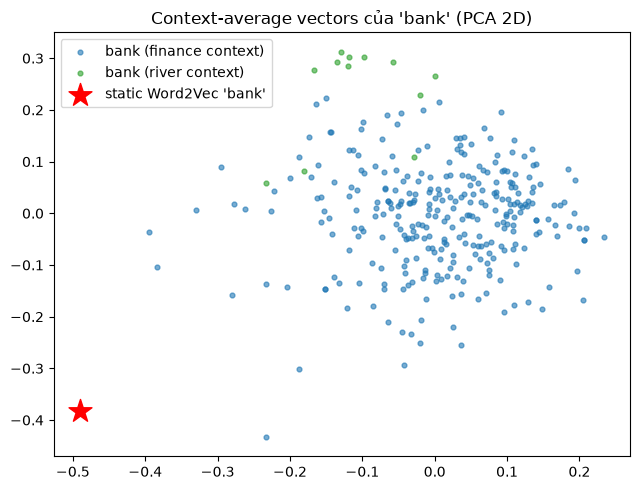

In [41]:
from sklearn.decomposition import PCA
plot_df = pd.concat([sub[sub["label"] == "finance"].sample(min(300, (sub["label"] == "finance").sum()), random_state=SEED),
                     sub[sub["label"] == "river"]])
pts = np.vstack(list(plot_df["vec"]) + [bank_vec / np.linalg.norm(bank_vec)])
xy = PCA(n_components=2, random_state=SEED).fit_transform(pts)
fig, ax = plt.subplots(figsize=(6.5, 5))
for lab, color in (("finance", "tab:blue"), ("river", "tab:green")):
    mask = (plot_df["label"] == lab).values
    ax.scatter(xy[:-1][mask, 0], xy[:-1][mask, 1], s=12, alpha=0.6, c=color, label=f"bank ({lab} context)")
ax.scatter(*xy[-1], marker="*", s=300, c="red", label="static Word2Vec 'bank'")
ax.set_title("Context-average vectors của 'bank' (PCA 2D)"); ax.legend()
plt.tight_layout(); plt.show()

**Nhận xét:**
- Vector tĩnh của bank chỉ mang nghĩa tài chính: hsbc, barclays; cos(bank, river) = 0.29. Lý do: 414 lần nghĩa tài chính so với 12 lần nghĩa bờ sông.
- Context đủ để tách hai nghĩa: phân loại theo centroid gần nhất đúng 97% / 92%.
- Một vector duy nhất không biểu diễn được hai nghĩa. Đây là động lực cho contextual embedding.

## 14. Lưu results.csv

In [42]:
results_df = pd.DataFrame(results)
results_df.to_csv("results.csv", index=False)
print(len(results_df), "rows")
results_df.groupby("experiment").size()

677 rows


experiment
application_search     72
core_most_similar     105
corpus_size            26
error_analysis         15
eval_analogy           60
eval_benchmark         12
eval_similarity        71
exp1_c4                78
exp1_toy               30
exp2_inspect           70
exp2_word2vec           4
exp3_window            51
exp4_dimension         53
polysemy_bank          10
prediction1            20
dtype: int64